In [1]:
!pip install -U diffusers transformers torch torchvision torchaudio safetensors pillow matplotlib scikit-image open_clip_torch

In [2]:
import os
import gc
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    AutoencoderKL,
    UNet2DConditionModel,
)
from transformers import CLIPTokenizer, CLIPTextModel

from peft import LoraConfig
from diffusers.loaders import AttnProcsLayers
from diffusers.models.attention_processor import LoRAAttnProcessor

from skimage.metrics import structural_similarity as ssim
import open_clip

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [17]:
MODEL_NAME = "runwayml/stable-diffusion-v1-5"

INSTANCE_TOKEN = "sks"
CLASS_NAME = "man"

INSTANCE_PROMPT = f"photo of {INSTANCE_TOKEN} {CLASS_NAME}"
CLASS_PROMPT = f"photo of a {CLASS_NAME}"

DATA_DIR = Path("data")
INSTANCE_DIR = DATA_DIR / "instance_images"
CLASS_DIR = DATA_DIR / "class_images"

OUTPUT_DIR = Path("dreambooth_lora_notebook")
MODEL_OUT = OUTPUT_DIR / "model"
LORA_OUT = OUTPUT_DIR / "lora"
GENERATED_DIR = OUTPUT_DIR / "generated"

DEVICE = "cuda"
DTYPE = torch.float32

RESOLUTION = 384
NUM_CLASS_IMAGES = 30

TRAIN_BATCH_SIZE = 1
LEARNING_RATE = 1e-4
NUM_EPOCHS = 300
SAVE_EVERY_EPOCHS = 50
PRIOR_LOSS_WEIGHT = 1.0
TRAIN_TEXT_ENCODER = False
SEED = 42

NUM_INFERENCE_STEPS = 40
GUIDANCE_SCALE = 7.5

print("DEVICE:", DEVICE)
print("DTYPE:", DTYPE)
print("RESOLUTION:", RESOLUTION)

DEVICE: cuda
DTYPE: torch.float32
RESOLUTION: 384


In [4]:
INSTANCE_DIR.mkdir(parents=True, exist_ok=True)
CLASS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUT.mkdir(parents=True, exist_ok=True)
LORA_OUT.mkdir(parents=True, exist_ok=True)
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

clear_cuda()

Папки готовы.
Положи свои фото в: data/instance_images


In [5]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


def save_grid(images, save_path, cols=3):
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes)
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[ax] for ax in axes])

    for ax in axes.flatten():
        ax.axis("off")

    for ax, img in zip(axes.flatten(), images):
        ax.imshow(img)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()


def load_image(path, size=(384, 384)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return img


def pil_to_np(img):
    return np.array(img).astype(np.float32) / 255.0

Количество instance image: 10


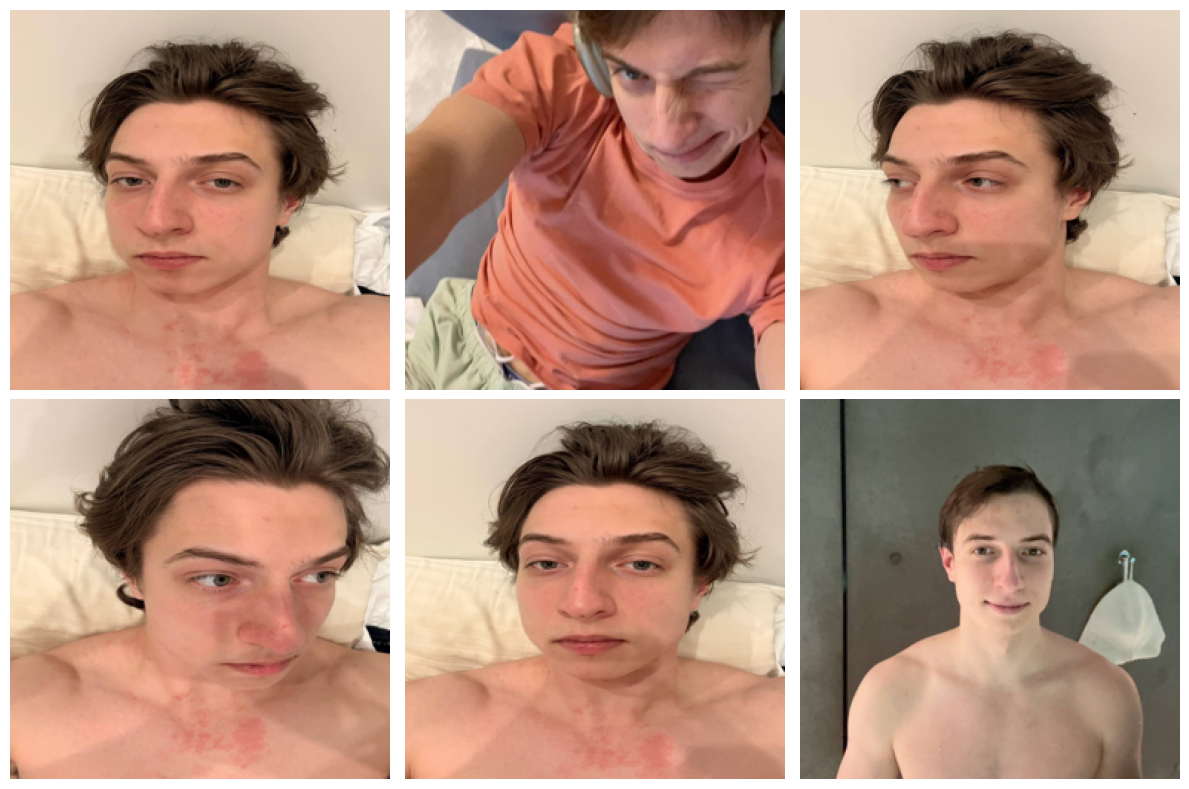

In [6]:
instance_files = sorted([
    p for p in INSTANCE_DIR.iterdir()
])

if len(instance_files) > 0:
    preview = [Image.open(p).convert("RGB").resize((256, 256)) for p in instance_files[:6]]
    save_grid(preview, OUTPUT_DIR / "instance_preview.png", cols=3)

In [7]:
def generate_class_images():
    existing = len(list(CLASS_DIR.glob("*.jpg")))
    if existing >= NUM_CLASS_IMAGES:
        print(f"[INFO] Class images already exist: {existing}")
        return

    print("[INFO] Generating class images...")
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_NAME,
        torch_dtype=DTYPE,
        safety_checker=None,
    ).to(DEVICE)

    pipe.enable_attention_slicing()

    to_generate = NUM_CLASS_IMAGES - existing
    for i in range(to_generate):
        image = pipe(
            CLASS_PROMPT,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            height=RESOLUTION,
            width=RESOLUTION,
        ).images[0]
        image.save(CLASS_DIR / f"class_{existing + i:03d}.jpg")

        if (i + 1) % 10 == 0:
            print(f"[INFO] Generated {i+1}/{to_generate}")

    del pipe
    clear_cuda()
    print("[INFO] Class images generated.")

In [8]:
generate_class_images()
clear_cuda()

[INFO] Class images already exist: 30


Количество class image: 30


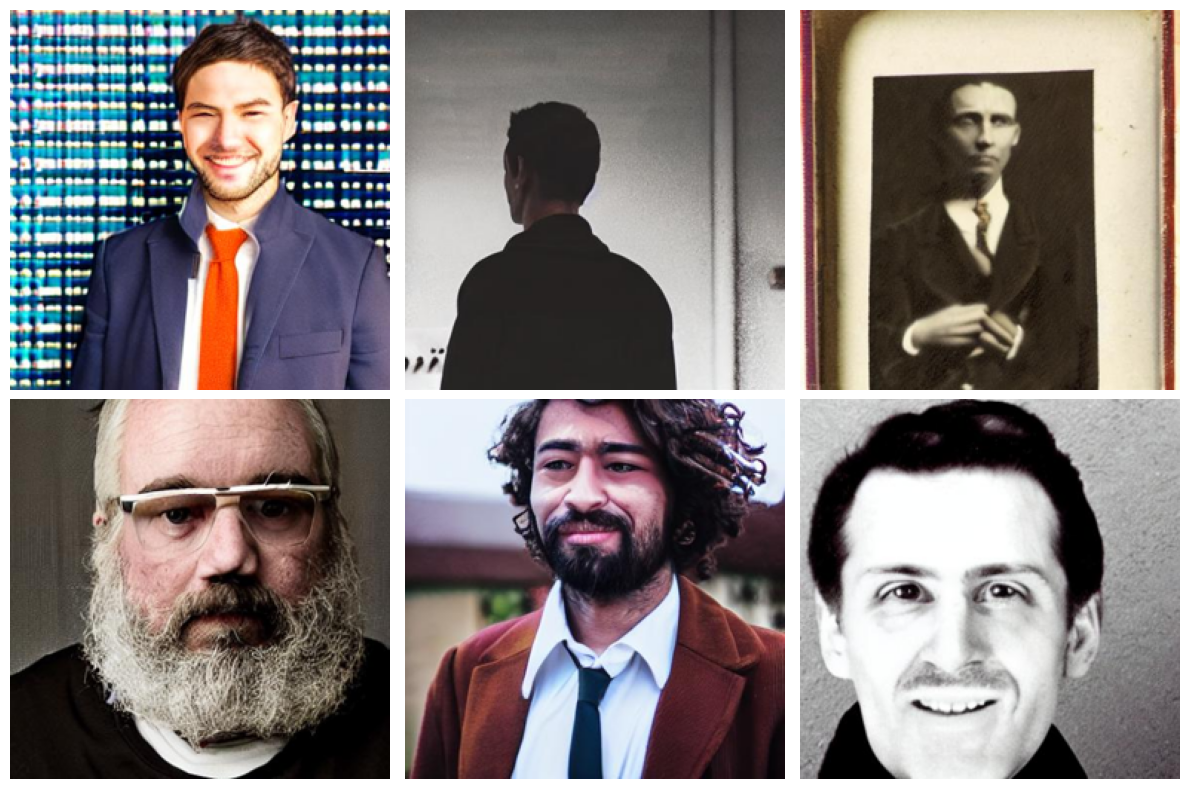

In [9]:
class_files = sorted([
    p for p in CLASS_DIR.iterdir()
])

preview = [Image.open(p).convert("RGB").resize((256, 256)) for p in class_files[:6]]
save_grid(preview, OUTPUT_DIR / "class_preview.png", cols=3)

In [10]:
class DreamBoothDataset(Dataset):
    def __init__(
        self,
        instance_data_root,
        class_data_root,
        instance_prompt,
        class_prompt,
        tokenizer,
        size=384,
        center_crop=True
    ):
        self.instance_data_root = Path(instance_data_root)
        self.class_data_root = Path(class_data_root)

        self.instance_images = sorted([
            p for p in self.instance_data_root.iterdir()
        ])
        self.class_images = sorted([
            p for p in self.class_data_root.iterdir()
        ])

        self.instance_prompt = instance_prompt
        self.class_prompt = class_prompt
        self.tokenizer = tokenizer
        self.size = size
        self.center_crop = center_crop

        self.num_instance_images = len(self.instance_images)
        self.num_class_images = len(self.class_images)
        self._length = max(self.num_instance_images, self.num_class_images)

        self.image_transforms = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return self._length

    def tokenize_prompt(self, prompt):
        inputs = self.tokenizer(
            prompt,
            truncation=True,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        )
        return inputs.input_ids[0]

    def __getitem__(self, index):
        instance_image = Image.open(self.instance_images[index % self.num_instance_images]).convert("RGB")
        class_image = Image.open(self.class_images[index % self.num_class_images]).convert("RGB")

        instance_tensor = self.image_transforms(instance_image)
        class_tensor = self.image_transforms(class_image)

        instance_ids = self.tokenize_prompt(self.instance_prompt)
        class_ids = self.tokenize_prompt(self.class_prompt)

        return {
            "instance_images": instance_tensor,
            "instance_prompt_ids": instance_ids,
            "class_images": class_tensor,
            "class_prompt_ids": class_ids,
        }


def collate_fn(examples):
    instance_images = torch.stack([e["instance_images"] for e in examples])
    class_images = torch.stack([e["class_images"] for e in examples])

    instance_prompt_ids = torch.stack([e["instance_prompt_ids"] for e in examples])
    class_prompt_ids = torch.stack([e["class_prompt_ids"] for e in examples])

    pixel_values = torch.cat([instance_images, class_images], dim=0)
    input_ids = torch.cat([instance_prompt_ids, class_prompt_ids], dim=0)

    return {
        "pixel_values": pixel_values,
        "input_ids": input_ids,
    }

In [11]:
print("[INFO] Loading tokenizer, text encoder, VAE, UNet, scheduler...")

tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

text_encoder.to(DEVICE, dtype=DTYPE)
vae.to(DEVICE, dtype=DTYPE)
unet.to(DEVICE, dtype=DTYPE)

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

unet.enable_gradient_checkpointing()

try:
    unet.enable_xformers_memory_efficient_attention()
    print("[INFO] xformers enabled")
except Exception as e:
    print("[INFO] xformers not available:", e)

lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    init_lora_weights="gaussian",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config)

trainable_params = [p for p in unet.parameters() if p.requires_grad]
print(f"[INFO] Trainable params: {sum(p.numel() for p in trainable_params):,}")

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)

print("[INFO] LoRA adapters added.")
clear_cuda()

[INFO] Loading tokenizer, text encoder, VAE, UNet, scheduler...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


[INFO] xformers not available: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
[INFO] Trainable params: 797,184
[INFO] LoRA adapters added.


In [12]:
dataset = DreamBoothDataset(
    instance_data_root=INSTANCE_DIR,
    class_data_root=CLASS_DIR,
    instance_prompt=INSTANCE_PROMPT,
    class_prompt=CLASS_PROMPT,
    tokenizer=tokenizer,
    size=RESOLUTION,
    center_crop=True,
)

dataloader = DataLoader(
    dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

print("Instance images:", dataset.num_instance_images)
print("Class images:", dataset.num_class_images)
print("Dataset length:", len(dataset))

Instance images: 10
Class images: 30
Dataset length: 30


In [13]:
def save_lora_weights(save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    unet.save_pretrained(save_dir)

    print(f"[INFO] LoRA weights saved to {save_dir}")

In [14]:
!pip install tqdm

from tqdm import tqdm

In [18]:
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

loss_history = []
instance_loss_history = []
prior_loss_history = []

epoch_mean_losses = []
epoch_mean_instance_losses = []
epoch_mean_prior_losses = []

global_step = 0

for epoch in tqdm(range(1, NUM_EPOCHS + 1)):

    epoch_losses = []
    epoch_instance_losses = []
    epoch_prior_losses = []

    unet.train()

    for batch_idx, batch in enumerate(dataloader):
        pixel_values = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
        input_ids = batch["input_ids"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                latents = vae.encode(pixel_values).latent_dist.sample()
                latents = latents * vae.config.scaling_factor
                encoder_hidden_states = text_encoder(input_ids)[0]

        noise = torch.randn_like(latents)
        bsz = latents.shape[0]

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (bsz,),
            device=latents.device
        ).long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states
            ).sample

        half = model_pred.shape[0] // 2
        model_pred_instance = model_pred[:half]
        model_pred_class = model_pred[half:]

        noise_instance = noise[:half]
        noise_class = noise[half:]

        instance_loss = F.mse_loss(model_pred_instance.float(), noise_instance.float(), reduction="mean")
        prior_loss = F.mse_loss(model_pred_class.float(), noise_class.float(), reduction="mean")
        loss = instance_loss + PRIOR_LOSS_WEIGHT * prior_loss

        if not torch.isfinite(loss):
            print(f"[WARNING] Non-finite loss at epoch={epoch}, batch={batch_idx}. Skipping.")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        global_step += 1

        loss_history.append(loss.item())
        instance_loss_history.append(instance_loss.item())
        prior_loss_history.append(prior_loss.item())

        epoch_losses.append(loss.item())
        epoch_instance_losses.append(instance_loss.item())
        epoch_prior_losses.append(prior_loss.item())

    mean_loss = float(np.mean(epoch_losses))
    mean_instance_loss = float(np.mean(epoch_instance_losses))
    mean_prior_loss = float(np.mean(epoch_prior_losses))

    epoch_mean_losses.append(mean_loss)
    epoch_mean_instance_losses.append(mean_instance_loss)
    epoch_mean_prior_losses.append(mean_prior_loss)

    if epoch % SAVE_EVERY_EPOCHS == 0:
        save_lora_weights(LORA_OUT / f"checkpoint-epoch-{epoch}")

    clear_cuda()

save_lora_weights(LORA_OUT / "final")
print("[INFO] Training finished.")

/tmp/ipykernel_8888/3586479530.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_8888/3586479530.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_8888/3586479530.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
 17%|█▋        | 50/300 [17:36<2:56:39, 42.40s/it]

[INFO] LoRA weights saved to dreambooth_lora_notebook/lora/checkpoint-epoch-50


 33%|███▎      | 100/300 [35:49<3:10:39, 57.20s/it]

[INFO] LoRA weights saved to dreambooth_lora_notebook/lora/checkpoint-epoch-100


 50%|█████     | 150/300 [54:16<2:34:24, 61.77s/it]

...

 83%|████████▎ | 250/300 [1:30:42<45:42, 54.85s/it]

[INFO] LoRA weights saved to dreambooth_lora_notebook/lora/checkpoint-epoch-250


100%|██████████| 300/300 [1:49:13<00:00, 21.85s/it]

[INFO] LoRA weights saved to dreambooth_lora_notebook/lora/checkpoint-epoch-300


[INFO] LoRA weights saved to dreambooth_lora_notebook/lora/final
[INFO] Training finished.


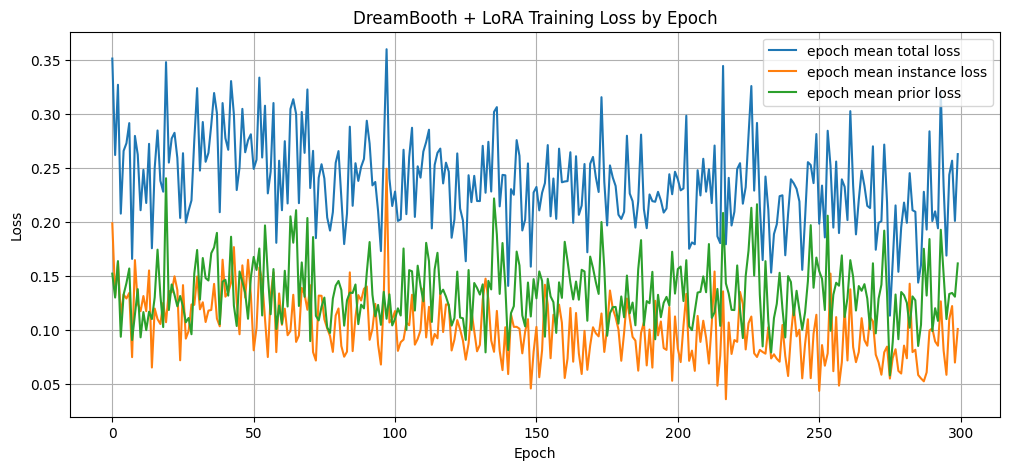

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(epoch_mean_losses, label="epoch mean total loss")
plt.plot(epoch_mean_instance_losses, label="epoch mean instance loss")
plt.plot(epoch_mean_prior_losses, label="epoch mean prior loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DreamBooth + LoRA Training Loss by Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
from safetensors.torch import load_file
from peft import LoraConfig

In [38]:
def load_trained_lora_unet(base_model_name, lora_dir, device, dtype):
    unet = UNet2DConditionModel.from_pretrained(
        base_model_name,
        subfolder="unet",
        torch_dtype=dtype,
    )

    lora_config = LoraConfig(
        r=4,
        lora_alpha=4,
        init_lora_weights="gaussian",
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    )

    unet.add_adapter(lora_config)

    state_dict = load_file(str(Path(lora_dir) / "diffusion_pytorch_model.safetensors"))
    missing, unexpected = unet.load_state_dict(state_dict, strict=False)

    print("[INFO] Missing keys:", len(missing))
    print("[INFO] Unexpected keys:", len(unexpected))

    return unet.to(device)

In [39]:
clear_cuda()

trained_unet = load_trained_lora_unet(
    base_model_name=MODEL_NAME,
    lora_dir=LORA_OUT / "final",
    device=DEVICE,
    dtype=DTYPE,
)

gen_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    unet=trained_unet,
    torch_dtype=DTYPE,
    safety_checker=None,
).to(DEVICE)

gen_pipe.enable_attention_slicing()

print("[INFO] Pipeline with trained LoRA loaded.")

[INFO] Missing keys: 0
[INFO] Unexpected keys: 0


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

[INFO] Pipeline with trained LoRA loaded.


In [40]:
prompts = [
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} in a cyberpunk city, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} made of metal, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} in an elven city, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} in a forest, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} in a city, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME} on a beach, high quality, realism, face close-up",
    f"photo of {INSTANCE_TOKEN} {CLASS_NAME}, face close-up"
]

for p in prompts:
    print(p)

photo of sks man in a cyberpunk city, high quality, realism, face close-up
photo of sks man made of metal, high quality, realism, face close-up
photo of sks man in an elven city, high quality, realism, face close-up
photo of sks man in a forest, high quality, realism, face close-up
photo of sks man in a city, high quality, realism, face close-up
photo of sks man on a beach, high quality, realism, face close-up
photo of sks man, face close-up


In [48]:
generated_images = []

for i, prompt in enumerate(prompts, 1):
    image = gen_pipe(
        prompt,
        num_inference_steps=50,
        guidance_scale=7.5,
        height=RESOLUTION,
        width=RESOLUTION,
    ).images[0]

    out_path = GENERATED_DIR / f"result_{i}.jpg"
    image.save(out_path)
    generated_images.append(image)

    print(f"[INFO] Saved {out_path}")

  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Saved dreambooth_lora_notebook/generated/result_1.jpg


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Saved dreambooth_lora_notebook/generated/result_2.jpg


  0%|          | 0/50 [00:00<?, ?it/s]

...

[INFO] Saved dreambooth_lora_notebook/generated/result_5.jpg


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Saved dreambooth_lora_notebook/generated/result_6.jpg


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Saved dreambooth_lora_notebook/generated/result_7.jpg


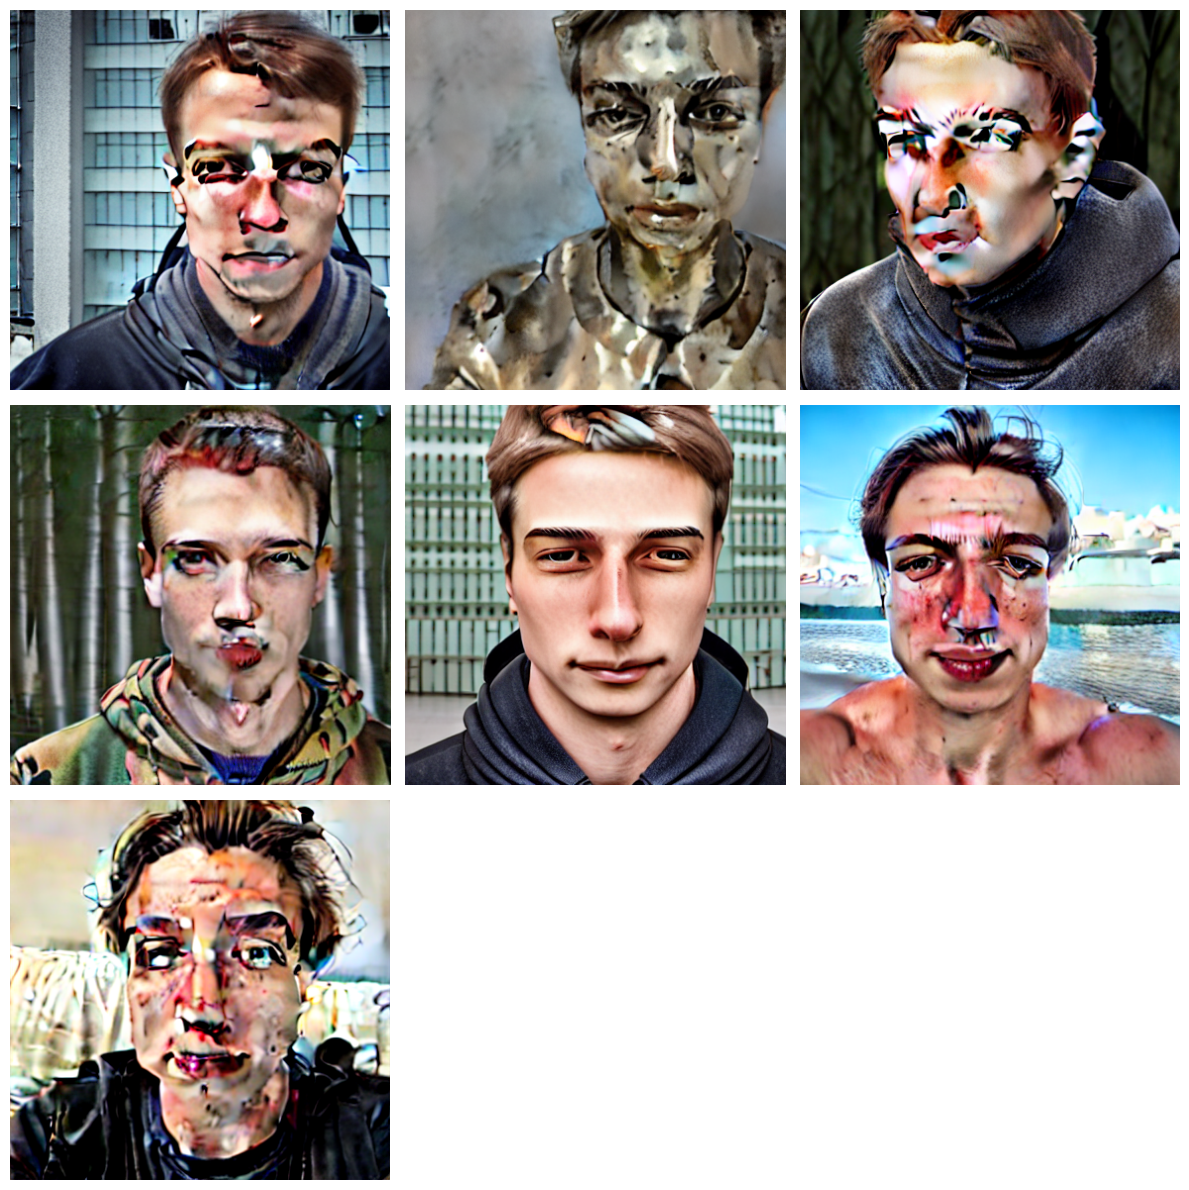

In [49]:
save_grid(generated_images, GENERATED_DIR / "grid.png", cols=3)

In [28]:
def compute_ssim_between_sets(real_paths, generated_paths):
    real_images = [load_image(p) for p in real_paths]
    gen_images = [load_image(p) for p in generated_paths]

    scores = []
    for g in gen_images:
        g_np = pil_to_np(g)
        best = -1
        for r in real_images:
            r_np = pil_to_np(r)
            score = ssim(r_np, g_np, channel_axis=2, data_range=1.0)
            best = max(best, score)
        scores.append(best)

    return float(np.mean(scores))

In [29]:
def compute_clip_text_score(generated_paths, prompts):
    model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    tokenizer_clip = open_clip.get_tokenizer("ViT-B-32")
    model = model.to(DEVICE)
    model.eval()

    scores = []

    with torch.no_grad():
        for img_path, prompt in zip(generated_paths, prompts):
            img = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
            text = tokenizer_clip([prompt]).to(DEVICE)

            image_features = model.encode_image(img)
            text_features = model.encode_text(text)

            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            score = (image_features @ text_features.T).item()
            scores.append(score)

    return float(np.mean(scores))

In [31]:
def compute_clip_identity_score(real_paths, generated_paths):
    model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    model = model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        real_feats = []
        for p in real_paths:
            img = preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
            feat = model.encode_image(img)
            feat /= feat.norm(dim=-1, keepdim=True)
            real_feats.append(feat)

        scores = []
        for p in generated_paths:
            img = preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
            gfeat = model.encode_image(img)
            gfeat /= gfeat.norm(dim=-1, keepdim=True)

            sims = [(gfeat @ rf.T).item() for rf in real_feats]
            scores.append(max(sims))

    return float(np.mean(scores))

In [32]:
real_paths = sorted([
    str(p) for p in INSTANCE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
])

generated_paths = sorted([
    str(p) for p in GENERATED_DIR.glob("result_*.jpg")
])

ssim_score = compute_ssim_between_sets(real_paths, generated_paths)
clip_text_score = compute_clip_text_score(generated_paths, prompts)
clip_identity_score = compute_clip_identity_score(real_paths, generated_paths)

print("===== QUALITY METRICS =====")
print(f"SSIM: {ssim_score:.4f}")
print(f"CLIP text-image similarity: {clip_text_score:.4f}")
print(f"CLIP identity similarity: {clip_identity_score:.4f}")

===== QUALITY METRICS =====
SSIM: 0.2291
CLIP text-image similarity: 0.2653
CLIP identity similarity: 0.6894


In [33]:
with open(OUTPUT_DIR / "metrics.txt", "w", encoding="utf-8") as f:
    f.write("QUALITY METRICS\n")
    f.write(f"SSIM: {ssim_score:.4f}\n")
    f.write(f"CLIP text-image similarity: {clip_text_score:.4f}\n")
    f.write(f"CLIP identity similarity: {clip_identity_score:.4f}\n")

print("Метрики сохранены в", OUTPUT_DIR / "metrics.txt")

Метрики сохранены в dreambooth_lora_notebook/metrics.txt


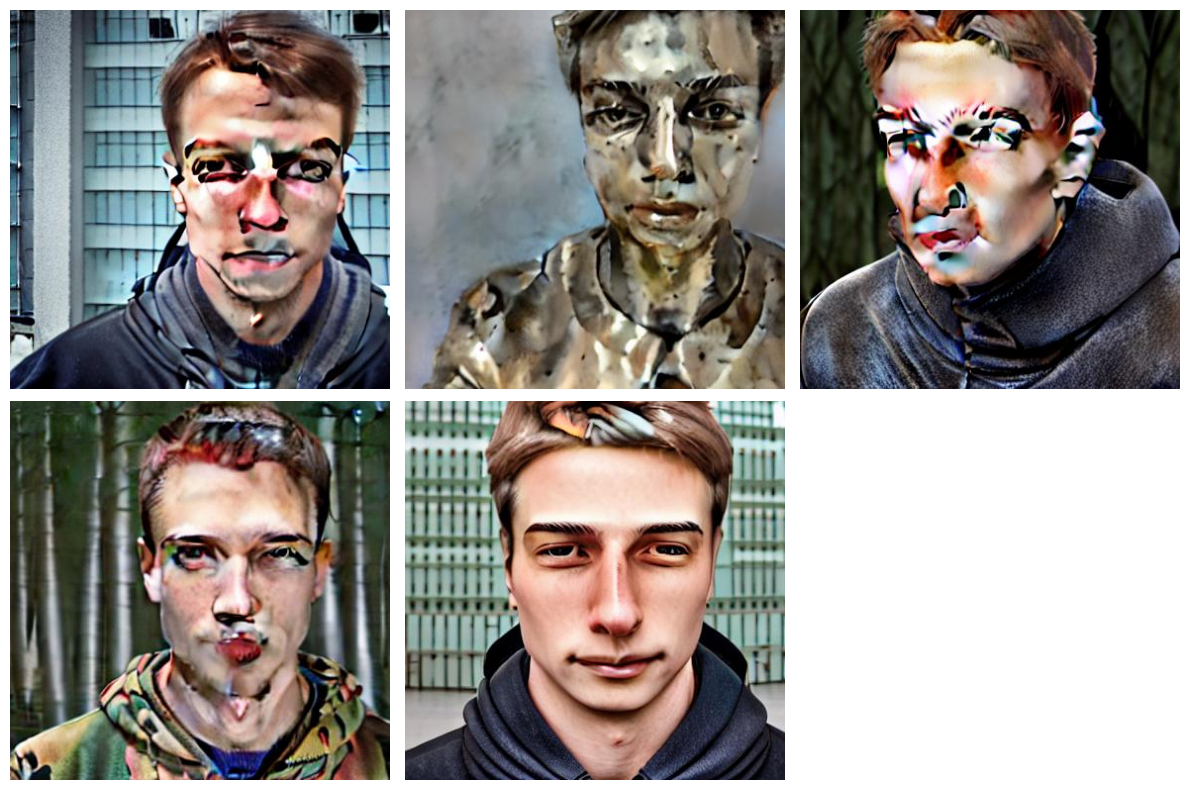

In [50]:
best_5_paths = generated_paths[:5]
best_5_images = [Image.open(p).convert("RGB") for p in best_5_paths]
save_grid(best_5_images, GENERATED_DIR / "best5.png", cols=3)